<a href="https://colab.research.google.com/github/Richard9235/NLP-Fundamentals-and-Application-Sentiment-Topic-and-Customer-Segmentation-./blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Natrual Language Processing (NLP)

<h3>Import necessary libraries</h3>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import zipfile

<h3>Extracting the dataset</h3>

In [ ]:
zip_file_path = r"/content/drive/MyDrive/Python Bootcamp Uplift Datasets/Women's E-Commerce Clothing Reviews.zip"
file_folder_path = r"/content/drive/MyDrive/Python Bootcamp Uplift Datasets/"
with zipfile.ZipFile(zip_file_path) as zip_ref:
    zip_ref.extractall(file_folder_path)
file_path = r"/content/drive/MyDrive/Python Bootcamp Uplift Datasets/Womens Clothing E-Commerce Reviews.csv"

<h3>Initial look at the dataset</h3>

In [ ]:
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
df.tail()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23485,23485,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


<h4>Why Encoding doesn't work on raw human language</h4>

- `Traditional Encoding` only works for categorical dataset
- `Encoding` is replacing text with a number
- `One Hot Encoding` gurantees no ordinal values in the dataset

<h3>What we'll be using instead of Encoding</h3>

<h4>Vectorization</h4>

- Concept:
  - We show the model a dictionary of raw human written texts
  - `Vector Map`: Model creates a map that groups almost similar meaning and those words usually seen together
  - `Vector Map` is a guide for the model to understand human language

- The model in question are `transformer models`, specifically, `sentiment models`


<h3>Text Analysis</h3>


In [ ]:
sentiment_model = "cardiffnlp/twitter-roberta-base-sentiment" # Model Name
classifier = pipeline("sentiment-analysis", model = sentiment_model, tokenizer = sentiment_model )# Model Instance

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

<h5> Classifier Parameters</h5>

1. What you want the model to do (sentiment-analysis)
2. What model you want to use (model = sentiment model variable)
3. Which subset model do you want to be responsible for transforming text information into token(tokenizer = sentiment model variable)

- Tokens are used to make the vector maps
- Tokenizers look at the dataset(text) and transforms it into a map compatible format(Vector Map)
- `cardiffnlp` already comes with a prebuilt tokenizer in its model so we don't need a separate tokenizer model


In [ ]:
sample_text = "I hate you."

In [ ]:
classifier(sample_text)

[{'label': 'LABEL_0', 'score': 0.9608864784240723}]

The cardiffnlp model has `3` Labels:
- "Positive" (Label 2)
- "Negative" (Label 0)
- "Neutral" (Label 1)

The score is the confidence level of the model || how close the label is to the text

In [ ]:
sample_text2 = "I have work tomorrow."
classifier(sample_text2)

[{'label': 'LABEL_1', 'score': 0.5419793725013733}]

In [ ]:
sample_text3 = "I'm totally fine'."
classifier(sample_text3)

[{'label': 'LABEL_2', 'score': 0.8484116196632385}]

In [ ]:
sample_text4 = "My wedding is tomorrow."
classifier(sample_text4)

[{'label': 'LABEL_1', 'score': 0.6673590540885925}]

In [ ]:
sample_text5 = "Pagod na ako."
classifier(sample_text5)
# Make sure that the model used is trained using the same language as the input as it would not recognize the text sentiment

[{'label': 'LABEL_1', 'score': 0.7150399088859558}]

<h3> Rudimentary Cleaning in order to enforce that columns are in text format</h3>

In [ ]:
df['Review Text'] = df['Review Text'].fillna('').astype(str)

- `fillna` Takes all the NA(Not Applicable) fields to use an empty string ('') instead of NA
- `astype` converts fields into a string for users who type in numerical values

In [ ]:
df_smaller = df[:30]

In [ ]:
results = classifier(df_smaller['Review Text'].tolist())

In [ ]:
df_smaller['sentiment_label'] = [indiv_result["label"] for indiv_result in results]
df_smaller['sentiment_score'] = [indiv_score["score"] for indiv_score in results]

/tmp/ipykernel_16338/2086163596.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smaller['sentiment_label'] = [indiv_result["label"] for indiv_result in results]
/tmp/ipykernel_16338/2086163596.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smaller['sentiment_score'] = [indiv_score["score"] for indiv_score in results]


In [ ]:
df_smaller[['Review Text', "sentiment_label", 'sentiment_score']].head(4)

,Review Text,sentiment_label,sentiment_score
0,Absolutely wonderful - silky and sexy and comf...,LABEL_2,0.987180
1,Love this dress! it's sooo pretty. i happene...,LABEL_2,0.990955
2,I had such high hopes for this dress and reall...,LABEL_1,0.380140
3,"I love, love, love this jumpsuit. it's fun, fl...",LABEL_2,0.993131


In [ ]:
df_smaller[['Review Text', "sentiment_label", 'sentiment_score']].tail(4)

,Review Text,sentiment_label,sentiment_score
26,I have been waiting for this sweater coat to s...,LABEL_1,0.385675
27,The colors weren't what i expected either. the...,LABEL_0,0.552147
28,I have several of goodhyouman shirts and i get...,LABEL_2,0.951048
29,This sweater is so comfy and classic - it bala...,LABEL_2,0.979796


Additional Information:
- `Finetunning` is customizing a pretrained model to your use case
- `Finetunning` is giving the model a list of new words with indication of positive, negative, or neutral connotations

## To Do Task:

- Run the classification model for 2000 fields
- Perform Exploratory Data analysis for the data together with the new columns(Label and Score)
- Answer the ff:
  - Identify, using graphs, identify the products with positive and negative sentiments
  - Do the same for the division, department, and class, identify the division with positive and negative sentiments
  - Inspect correlation between the categories and the sentiment score.

In [ ]:
df_task = df[:2000]

In [ ]:
df_task

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,867,38,Material,Material is hard to wear a bra under it,2,0,0,General,Tops,Knits
1996,1996,927,48,NaN,Very soft fabric. does begin to ball up due to...,4,1,0,General Petite,Tops,Sweaters
1997,1997,1022,35,NaN,These jeans hug in all the right places. the h...,5,1,0,General,Bottoms,Jeans
1998,1998,164,25,Super comfy,Loved the way these felt but like the previous...,4,1,0,Initmates,Intimate,Lounge


In [ ]:
results = classifier(df_task['Review Text'].tolist())

In [ ]:
df_task['sentiment_label'] = [indiv_result["label"] for indiv_result in results]
df_task['sentiment_score'] = [indiv_score["score"] for indiv_score in results]

/tmp/ipykernel_16338/3491426429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_task['sentiment_label'] = [indiv_result["label"] for indiv_result in results]
/tmp/ipykernel_16338/3491426429.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_task['sentiment_score'] = [indiv_score["score"] for indiv_score in results]


<H5> I'll be using (bar chart, boxplot, pie chart) for visualization</H5>

In [ ]:
df_task

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,sentiment_label,sentiment_score
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,LABEL_2,0.987180
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,LABEL_2,0.990955
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,LABEL_1,0.380140
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,LABEL_2,0.993131
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,LABEL_2,0.992028
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,867,38,Material,Material is hard to wear a bra under it,2,0,0,General,Tops,Knits,LABEL_0,0.484081
1996,1996,927,48,NaN,Very soft fabric. does begin to ball up due to...,4,1,0,General Petite,Tops,Sweaters,LABEL_1,0.643741
1997,1997,1022,35,NaN,These jeans hug in all the right places. the h...,5,1,0,General,Bottoms,Jeans,LABEL_2,0.785168
1998,1998,164,25,Super comfy,Loved the way these felt but like the previous...,4,1,0,Initmates,Intimate,Lounge,LABEL_2,0.952134


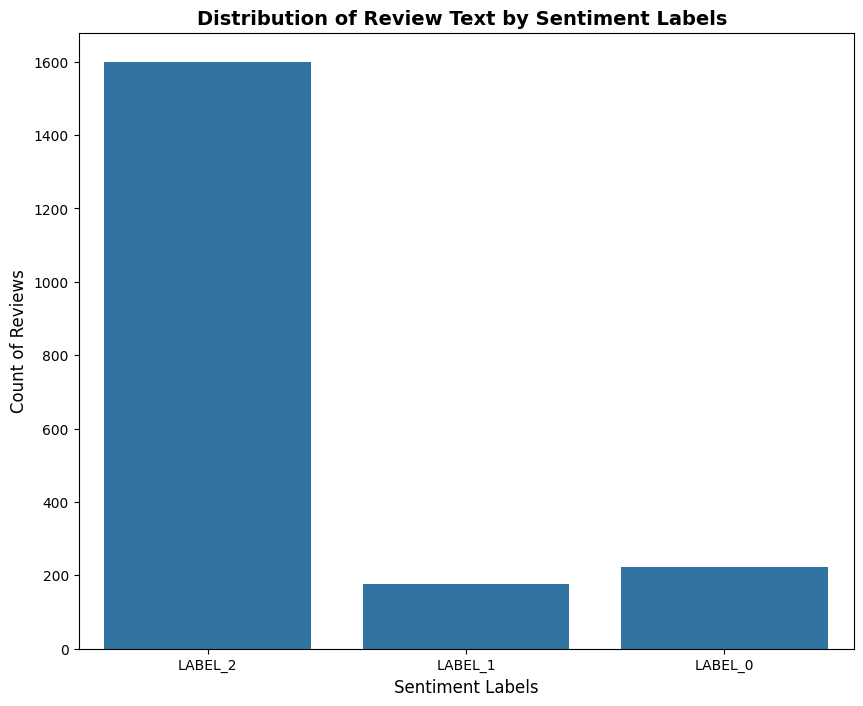

In [ ]:
# Bar Graph
plt.figure(figsize=(10, 8))
sns.countplot(data=df_task, x='sentiment_label')

plt.title('Distribution of Review Text by Sentiment Labels ', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Labels', fontsize=12)
plt.ylabel('Count of Reviews', fontsize=12)
plt.show()

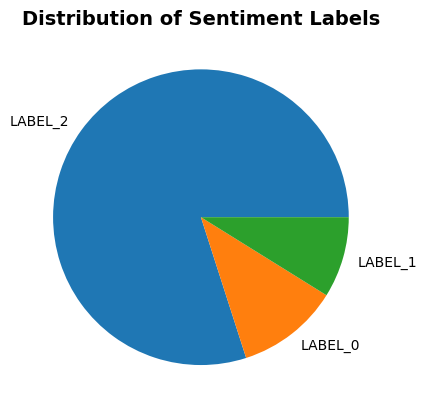

In [ ]:
#Pie Chart
labels = df_task["sentiment_label"].value_counts().index
sizes = df_task["sentiment_label"].value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels)
plt.title('Distribution of Sentiment Labels', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
division_results = classifier(df_task['Division Name'].tolist())

KeyboardInterrupt: 

In [ ]:
class_results = classifier(df_task['Class Name'].tolist())

KeyboardInterrupt: 

In [ ]:
department_results = classifier(df_task['Department Name'].tolist())

## NLP Methodologies

### Dimensionality Reduction
- For datasets with more than 10 columns
- Tries to collapse columns into smaller number of columns via `multi-colinear dependency`
- `Multi-Colinear Dependency` combines columns that can be inferred from one another
- An advantage of dimensionality reduction is that it helps with `computational efficiency`

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [ ]:
num_cols = df_smaller.select_dtypes(["int","float"]).columns
cat_cols = df_smaller.select_dtypes(["object"]).columns

In [ ]:
transformation_pipeline = ColumnTransformer([
    ("num", SimpleImputer(strategy = "median"), num_cols),
    ("scaler", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

*Refresher: SimpleImputer just replaces the value with the median/mode/mean*

In [ ]:
df_smaller_trans = transformation_pipeline.fit_transform(df_smaller)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca_model = PCA(n_components=2)

- `n_components` defines the amount of columns you want to reduce your dataset to
- In our case, we'd be reducing our dataset to only have 2 columns
- To identify which column number should we reduce the dataset to, it's a `trial-and-error` process to be validated by our tests.

In [ ]:
df_pca = pca_model.fit_transform(df_smaller_trans)

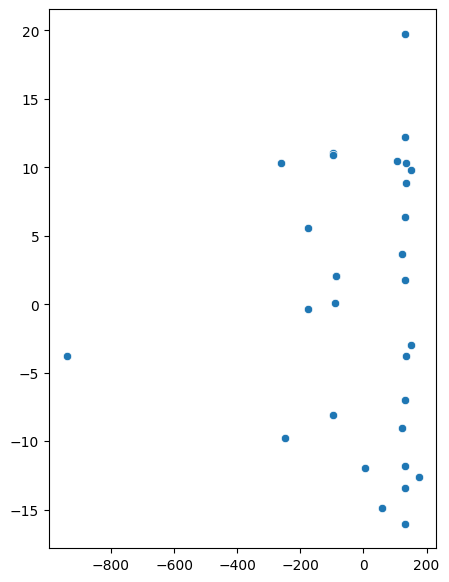

In [ ]:
plt.figure(figsize=(5,7))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1])
plt.show()

### KMeans Clustering
- 1 Specific method of `segmentation/clustering`



In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans_model = KMeans(n_clusters=3, random_state = 42, n_init = 10)

- `n_clusters` a distinct guess of the groups of your dataset
- `random_state` puts a tag on the starting point so that it gives out consistent results when rerunning
- `n_init` how many times the model runs before the operation stops, better outcomes the higher the number with the cost of longer processing time

In [ ]:
clusters = kmeans_model.fit_predict(df_pca)

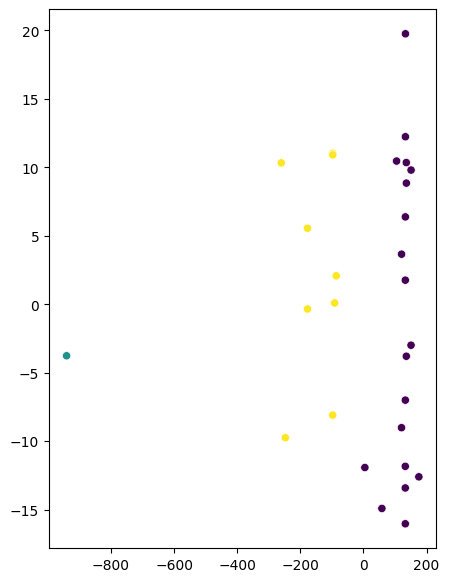

In [ ]:
plt.figure(figsize=(5,7))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], c=clusters)
plt.show()

In [ ]:
df_smaller['cluster'] = clusters

/tmp/ipykernel_16338/3517241506.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smaller['cluster'] = clusters


In [ ]:
df_smaller.head(10)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,sentiment_label,sentiment_score,cluster
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,LABEL_2,0.987180,2
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,LABEL_2,0.990955,0
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,LABEL_1,0.380140,0
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,LABEL_2,0.993131,0
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,LABEL_2,0.992028,2
5,5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,LABEL_2,0.545943,0
6,6,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,LABEL_2,0.922028,2
7,7,858,39,"Shimmer, surprisingly goes with lots","I ordered this in carbon for store pick up, an...",4,1,4,General Petite,Tops,Knits,LABEL_2,0.848489,2
8,8,1077,24,Flattering,I love this dress. i usually get an xs but it ...,5,1,0,General,Dresses,Dresses,LABEL_2,0.987146,0
9,9,1077,34,Such a fun dress!,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5,1,0,General,Dresses,Dresses,LABEL_2,0.969403,0


### Elbow Method

In [ ]:
inertias =  []
number_clusters = range(1,10)

for number_cluster in number_clusters:
  kmeans_model = KMeans(n_clusters=number_cluster, random_state = 42, n_init = 10)
  kmeans_model.fit(df_pca)
  inertias.append(kmeans_model.inertia_)

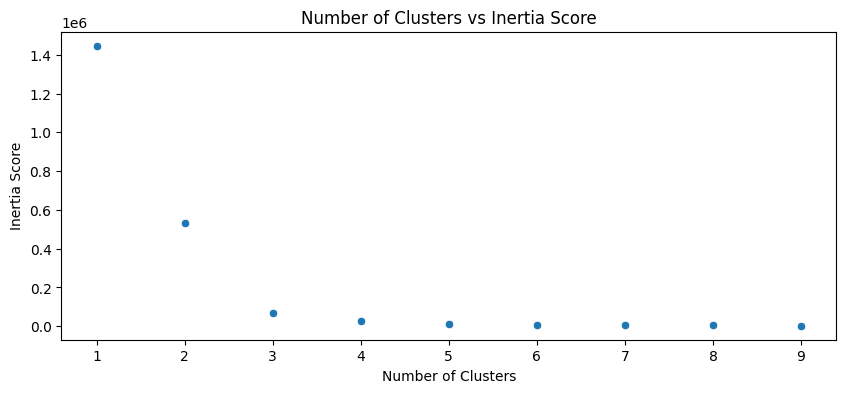

In [ ]:
plt.figure(figsize=(10,4))
sns.scatterplot(x=number_clusters, y= inertias)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia Score")
plt.title("Number of Clusters vs Inertia Score")
plt.show()

- `Inertia` is the likelyhood of the data defecting from the cluster
- Elbow Method identifies the optimal number of clusters to use for KMeans.
- In our case, the elbow is located at `3`, therefore, we should use 3 for our `n-clusters` at our KMeans model instance
- Should be performed before implementing the KMeans
- The lower the inertia score, the better

<h6>Review of Process</h6>

1. Perform Dimensionality Reduction to reduce number of columns to `2`
2. Plot a 2 dimensional graph
3. Perform the elbow method to find the optimal `n_clustering` number
4. Perform KMeans clustering, inputting `n_clustering` with the optimal number.
5. Create a graph again for KMeans but this time to specify differnt colors for different clusters
6. Lastly, we create a new column on our dataset with our identified clusters

<h5>Interview Review</h5>

1. How would you explain Sentiment Analysis, Dimensionality Reduction, and Customer Segmentation?

Answer:
- Sentiment Analysis deals with the combination of vectorization and classifiers wherein classifiers are the models themselves acting as a scorer to identify whether the input's sentiment is positive, negative, or neutral whilst vectorization is the act of transforming our data into vector maps or as Sir Cielo described it, geolocation coordinates for the model to use.
- Dimensionality Reduction is the act of abstracting our dataset by reducing the number of our columns to our desired number, in our case we reduced our fashion review dataset to 2
- Customer Segmentation is the combination of both KMeans clustering and the elbow method wherein we identified the optimal number of clusters via the elbow method and used that to group our datas into clusters via KMeans. We then created a new column to visualize the results of KMeans.

2. Explain it in one sentence

Answer:
- Sentiment Analysis is the act of identifying the sentiment of the user input, Dimensionality Reduction is reducing the amount of columns of a given dataset, and Customer Segmentation is the act of clustering fields in our dataset

### Topic Classification

In [ ]:
from transformers import pipeline

In [ ]:
candidate_topics = ['Fast Delivery', ' Good Communication', 'Quality of Products', 'Handling', 'Price', 'Packaging']

*We're always required to create a list of candidate topics*

In [ ]:
topic_classifier = pipeline("zero-shot-classification", model = 'facebook/bart-large-mnli')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

- Zero Shot is named zero shot because we don't have to train the model in order for it to classify topics
- Regular classification requires us to teach the model the dataset inorder for it to classify data, whilst zero shot doesn't require dataset training anymore because it comes with it out of the box.

In [ ]:
sample_review = "I received the product on time."

In [ ]:
result = topic_classifier(sample_review, candidate_topics)

In [ ]:
result

{'sequence': 'I received the product on time.',
 'labels': ['Fast Delivery',
  'Quality of Products',
  ' Good Communication',
  'Price',
  'Handling',
  'Packaging'],
 'scores': [0.5614520907402039,
  0.2746032774448395,
  0.10145489126443863,
  0.027615860104560852,
  0.02275443635880947,
  0.012119404040277004]}

In [ ]:
result['labels'][0], result['scores'][0]*100

('Fast Delivery', 56.145209074020386)

In [ ]:
sample_review2 = "The jeans are decent for the price point but the shipping took nearly two weeks to arrive and the packaging was slightly torn when it got here."
result2 = topic_classifier(sample_review2, candidate_topics)
result2

{'sequence': 'The jeans are decent for the price point but the shipping took nearly two weeks to arrive and the packaging was slightly torn when it got here.',
 'labels': ['Price',
  'Packaging',
  'Quality of Products',
  'Handling',
  ' Good Communication',
  'Fast Delivery'],
 'scores': [0.3992658257484436,
  0.2488381266593933,
  0.1619926244020462,
  0.12785013020038605,
  0.044702306389808655,
  0.01735096052289009]}

In [ ]:
df_smaller.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,sentiment_label,sentiment_score,cluster
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,LABEL_2,0.987180,2
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,LABEL_2,0.990955,0
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,LABEL_1,0.380140,0
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,LABEL_2,0.993131,0
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,LABEL_2,0.992028,2


In [ ]:
customer_reviews = df_smaller["Review Text"].tolist()

In [ ]:
topics = []
for review in customer_reviews:
  result = topic_classifier(review, candidate_topics)
  topic = result["labels"][0]
  topics.append(topic)


In [ ]:
df_smaller['topics'] = topics
df_smaller[['Review Text','topics']]

/tmp/ipykernel_16338/781688000.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smaller['topics'] = topics


,Review Text,topics
0,Absolutely wonderful - silky and sexy and comf...,Quality of Products
1,Love this dress! it's sooo pretty. i happene...,Quality of Products
2,I had such high hopes for this dress and reall...,Quality of Products
3,"I love, love, love this jumpsuit. it's fun, fl...",Quality of Products
4,This shirt is very flattering to all due to th...,Quality of Products
5,"I love tracy reese dresses, but this one is no...",Packaging
6,I aded this in my basket at hte last mintue to...,Quality of Products
7,"I ordered this in carbon for store pick up, an...",Quality of Products
8,I love this dress. i usually get an xs but it ...,Quality of Products
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",Quality of Products


In [ ]:
df_smaller['topics'].value_counts()

,count
topics,
Quality of Products,27
Price,2
Packaging,1


In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
filt = df_smaller["topics"] == "Packaging"
df_smaller[filt]


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,sentiment_label,sentiment_score,cluster,topics
5,5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress. the skirt is long and very full so it overwhelmed my small frame. not a stranger to alterations, shortening and narrowing the skirt would take away from the embellishment of the garment. i love the color and the idea of the style but it just did not work on me. i returned this dress.",2,0,4,General,Dresses,Dresses,LABEL_2,0.545943,0,Packaging


## To Do
1. Find your own dataset (Look for one on Kaggle)
2. Apply any of the four NLP methodologies
3. Visualization is applied twice, once on the raw dataset and once after the methodology

### Extracting the Dataset

In [ ]:
zip_file_path = r"/content/drive/MyDrive/Python Bootcamp Uplift Datasets/Facebook Reviews.zip"
file_folder_path = r"/content/drive/MyDrive/Python Bootcamp Uplift Datasets/"
with zipfile.ZipFile(zip_file_path) as zip_ref:
    zip_ref.extractall(file_folder_path)
fb = r"/content/drive/MyDrive/Python Bootcamp Uplift Datasets/facebook_reviews.csv"

### Initial Look at the data

In [ ]:
df_fb = pd.read_csv(fb)
df_fb.head()


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,28d4c82d-a63c-4c27-8eaa-9fdb2b08073e,Adeel Virk,"I used Facebook for selling local products, and it used to be great. But recently, it’s become extremely frustrating. Accounts and Marketplace access are getting randomly restricted or banned with no clear reason or warning. There’s no transparency at all, and the support system is completely useless. It’s now very difficult to run a small business like this. Honestly, Facebook is no longer a reliable platform for selling..",4,1,559.1.0.52.72,2026-05-07 01:43:34,559.1.0.52.72
1,23a5309b-f8f3-44ab-bf74-cf92a2dad20c,Roger Blair,"I'm not receiving notifications on Facebook like I'm suppose to. I've reported this problem several times a day since April 27, 2026 and nothing has been done about it. I have my settings setup to receive notifications from groups I belong to and setup to receive notifications from a lot of the pages I follow and haven't been receiving any notifications from them.",1,3,559.1.0.52.72,2026-05-07 00:14:13,559.1.0.52.72
2,134d44f1-4366-4149-a4cc-e6d1e181f59c,Rabia Shaheen W/O Salahuddin khilji (Bia khilji),"I used Facebook mainly for selling local products, and it used to be a great platform for that. But over the past month or so, things have gotten really frustrating. AI systems seem to be randomly suspending Marketplace access or banning accounts without any clear reason.There’s little to no explanation provided, and the support system is not helpful at all. It’s become very difficult to run a small business this way. Because of this, Facebook is no longer useful for me as a selling platform,",1,0,558.0.0.70.72,2026-05-07 01:22:52,558.0.0.70.72
3,16d717cf-47d9-45e9-8e48-eca0dae27260,paul mcnabb,"its all a pay to play now, robs you of views and traffic unless you pay them for verification badge and pay to promote. this business has just become so greedy that you cant have a presents unless you pay them or act as if its a job to post 3 4 times a day. and do reels. I dont want to live on your app. all they have done is make it harder to get the reach.",1,0,557.0.0.59.72,2026-05-07 01:55:17,557.0.0.59.72
4,ece2af88-e766-4a00-8735-cfd1066cac22,Katmar Berg,"My admin account was wrongfully disabled after I reported it being hacked. My business pages had been hijacked and are under the hackers' control. I tried every avenue to re-enstate my account and reclaim my business pages, but I got nowhere. I have evidence to prove everything, but I can't get anyone from Meta to help me.",1,0,559.1.0.52.72,2026-05-07 01:24:10,559.1.0.52.72


In [ ]:
df_fb.tail()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
355768,d7816c49-b04a-4069-b9f9-25e63d069a41,Deepak thakur Deepak thakur,nice video,5,0,NaN,2024-05-08 00:07:55,NaN
355769,c23d2b31-4c97-41de-867c-3f5ef3a61d0d,Joseph Leblanc,love it!!!,5,0,462.0.0.47.85,2024-05-08 00:07:38,462.0.0.47.85
355770,01bdb728-5042-4a8f-b207-8a02263c7b3e,Christian Kelechi,Good work is confirmed,5,0,361.0.0.39.115,2024-05-08 00:07:31,361.0.0.39.115
355771,a5207278-bc25-4bbb-b999-004407519b81,Mankhush Abinash,I NH by t um TV ex RV hu by,1,0,462.0.0.47.85,2024-05-08 00:04:41,462.0.0.47.85
355772,60cb051b-de1e-4081-970b-6b7cd7e3dc03,Trudy Musgrove,Works,3,0,NaN,2024-05-08 00:01:21,NaN


In [ ]:
rows, columns = df.shape
print('Number of Rows:', rows)
print('Number of Columns:', columns)

Number of Rows: 23486
Number of Columns: 11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              23486 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,0
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


### Data Visualization

### Initial Insights

### Initial Feature Engineering

In [ ]:
df_fb.dropna(inplace=True)
df_fb.isnull().sum()

,0
reviewId,0
userName,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,0
at,0
appVersion,0


### Exploratory Analysis

### Sentiment Analysis

In [ ]:
sentiment_model = "cardiffnlp/twitter-roberta-base-sentiment" # Model Name
classifier = pipeline("sentiment-analysis", model = sentiment_model, tokenizer = sentiment_model )# Model Instance

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
df_fb_smaller = df_fb[:2000]

In [ ]:
results = classifier(df_fb_smaller['content'].tolist(), truncation=True)
df_fb_smaller['sentiment_label'] = [indiv_result["label"] for indiv_result in results]
df_fb_smaller['sentiment_score'] = [indiv_score["score"] for indiv_score in results]

/tmp/ipykernel_16338/1720349589.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fb_smaller['sentiment_label'] = [indiv_result["label"] for indiv_result in results]
/tmp/ipykernel_16338/1720349589.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fb_smaller['sentiment_score'] = [indiv_score["score"] for indiv_score in results]


In [ ]:
df_fb_smaller

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,sentiment_label,sentiment_score
0,28d4c82d-a63c-4c27-8eaa-9fdb2b08073e,Adeel Virk,"I used Facebook for selling local products, and it used to be great. But recently, it’s become extremely frustrating. Accounts and Marketplace access are getting randomly restricted or banned with no clear reason or warning. There’s no transparency at all, and the support system is completely useless. It’s now very difficult to run a small business like this. Honestly, Facebook is no longer a reliable platform for selling..",4,1,559.1.0.52.72,2026-05-07 01:43:34,559.1.0.52.72,LABEL_0,0.926274
1,23a5309b-f8f3-44ab-bf74-cf92a2dad20c,Roger Blair,"I'm not receiving notifications on Facebook like I'm suppose to. I've reported this problem several times a day since April 27, 2026 and nothing has been done about it. I have my settings setup to receive notifications from groups I belong to and setup to receive notifications from a lot of the pages I follow and haven't been receiving any notifications from them.",1,3,559.1.0.52.72,2026-05-07 00:14:13,559.1.0.52.72,LABEL_0,0.778994
2,134d44f1-4366-4149-a4cc-e6d1e181f59c,Rabia Shaheen W/O Salahuddin khilji (Bia khilji),"I used Facebook mainly for selling local products, and it used to be a great platform for that. But over the past month or so, things have gotten really frustrating. AI systems seem to be randomly suspending Marketplace access or banning accounts without any clear reason.There’s little to no explanation provided, and the support system is not helpful at all. It’s become very difficult to run a small business this way. Because of this, Facebook is no longer useful for me as a selling platform,",1,0,558.0.0.70.72,2026-05-07 01:22:52,558.0.0.70.72,LABEL_0,0.928113
3,16d717cf-47d9-45e9-8e48-eca0dae27260,paul mcnabb,"its all a pay to play now, robs you of views and traffic unless you pay them for verification badge and pay to promote. this business has just become so greedy that you cant have a presents unless you pay them or act as if its a job to post 3 4 times a day. and do reels. I dont want to live on your app. all they have done is make it harder to get the reach.",1,0,557.0.0.59.72,2026-05-07 01:55:17,557.0.0.59.72,LABEL_0,0.893720
4,ece2af88-e766-4a00-8735-cfd1066cac22,Katmar Berg,"My admin account was wrongfully disabled after I reported it being hacked. My business pages had been hijacked and are under the hackers' control. I tried every avenue to re-enstate my account and reclaim my business pages, but I got nowhere. I have evidence to prove everything, but I can't get anyone from Meta to help me.",1,0,559.1.0.52.72,2026-05-07 01:24:10,559.1.0.52.72,LABEL_0,0.887845
...,...,...,...,...,...,...,...,...,...,...
2290,5ab4cc10-9389-4ff2-b5f7-8e4e0579d3ba,Sampath selvi,😭ப்,1,0,480.0.0.54.88,2024-10-04 02:34:01,480.0.0.54.88,LABEL_1,0.741450
2291,4a152595-fb15-4126-9e08-6febc8a6fa54,Riton Sk,rohimsk,3,0,483.0.0.51.72,2024-10-04 02:33:28,483.0.0.51.72,LABEL_1,0.693862
2292,5bdb81ee-e7f2-4bc9-b0be-85f5866f58e8,DINANATH PRASAD,very good,5,0,180.0.0.35.82,2024-10-04 02:33:22,180.0.0.35.82,LABEL_2,0.948211
2293,92f3a3c4-4121-4ae3-8973-fb77777740a4,Suresh Khanna,Nice app,5,0,483.0.0.51.72,2024-10-04 02:33:16,483.0.0.51.72,LABEL_2,0.903284


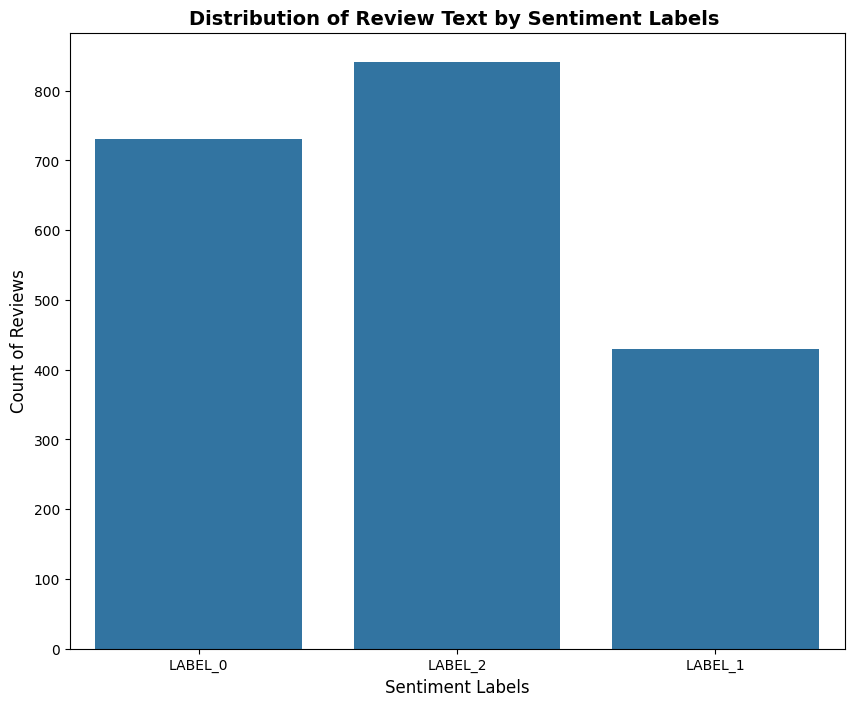

In [ ]:
# Bar Graph
plt.figure(figsize=(10, 8))
sns.countplot(data=df_fb_smaller, x='sentiment_label')

plt.title('Distribution of Review Text by Sentiment Labels ', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Labels', fontsize=12)
plt.ylabel('Count of Reviews', fontsize=12)
plt.show()

### Data Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [ ]:
df_fb.head(5)

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,28d4c82d-a63c-4c27-8eaa-9fdb2b08073e,Adeel Virk,"I used Facebook for selling local products, and it used to be great. But recently, it’s become extremely frustrating. Accounts and Marketplace access are getting randomly restricted or banned with no clear reason or warning. There’s no transparency at all, and the support system is completely useless. It’s now very difficult to run a small business like this. Honestly, Facebook is no longer a reliable platform for selling..",4,1,559.1.0.52.72,2026-05-07 01:43:34,559.1.0.52.72
1,23a5309b-f8f3-44ab-bf74-cf92a2dad20c,Roger Blair,"I'm not receiving notifications on Facebook like I'm suppose to. I've reported this problem several times a day since April 27, 2026 and nothing has been done about it. I have my settings setup to receive notifications from groups I belong to and setup to receive notifications from a lot of the pages I follow and haven't been receiving any notifications from them.",1,3,559.1.0.52.72,2026-05-07 00:14:13,559.1.0.52.72
2,134d44f1-4366-4149-a4cc-e6d1e181f59c,Rabia Shaheen W/O Salahuddin khilji (Bia khilji),"I used Facebook mainly for selling local products, and it used to be a great platform for that. But over the past month or so, things have gotten really frustrating. AI systems seem to be randomly suspending Marketplace access or banning accounts without any clear reason.There’s little to no explanation provided, and the support system is not helpful at all. It’s become very difficult to run a small business this way. Because of this, Facebook is no longer useful for me as a selling platform,",1,0,558.0.0.70.72,2026-05-07 01:22:52,558.0.0.70.72
3,16d717cf-47d9-45e9-8e48-eca0dae27260,paul mcnabb,"its all a pay to play now, robs you of views and traffic unless you pay them for verification badge and pay to promote. this business has just become so greedy that you cant have a presents unless you pay them or act as if its a job to post 3 4 times a day. and do reels. I dont want to live on your app. all they have done is make it harder to get the reach.",1,0,557.0.0.59.72,2026-05-07 01:55:17,557.0.0.59.72
4,ece2af88-e766-4a00-8735-cfd1066cac22,Katmar Berg,"My admin account was wrongfully disabled after I reported it being hacked. My business pages had been hijacked and are under the hackers' control. I tried every avenue to re-enstate my account and reclaim my business pages, but I got nowhere. I have evidence to prove everything, but I can't get anyone from Meta to help me.",1,0,559.1.0.52.72,2026-05-07 01:24:10,559.1.0.52.72


In [ ]:

df_fb_smaller['content'] = df_fb_smaller['content'].fillna('').astype(str)

num_cols = df_fb_smaller.select_dtypes(["int","float"]).columns

cat_cols = df_fb_smaller.select_dtypes(["object"]).columns

transformation_pipeline = ColumnTransformer([
    ("num", SimpleImputer(strategy = "median"), num_cols),
    ("scaler", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

df_fb_smaller_trans = transformation_pipeline.fit_transform(df_fb_smaller)

/tmp/ipykernel_16338/3906631423.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fb_smaller['content'] = df_fb_smaller['content'].fillna('').astype(str)


### Dimensionality Reduction

In [ ]:
df_fb_smaller = transformation_pipeline.fit_transform(df_fb_smaller)

In [ ]:
from sklearn.decomposition import PCA
pca_model = PCA(n_components=2)

In [ ]:
df_pca_fb = pca_model.fit_transform(df_fb_smaller)

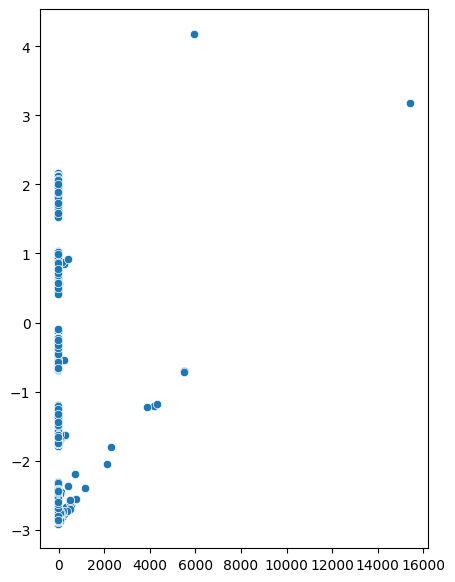

In [ ]:
plt.figure(figsize=(5,7))
sns.scatterplot(x=df_pca_fb[:,0], y=df_pca_fb[:,1])
plt.show()

### Elbow Method

In [ ]:
inertias =  []
number_clusters = range(1,10)

for number_cluster in number_clusters:
  kmeans_model = KMeans(n_clusters=number_cluster, random_state = 42, n_init = 10)
  kmeans_model.fit(df_pca_fb)
  inertias.append(kmeans_model.inertia_)

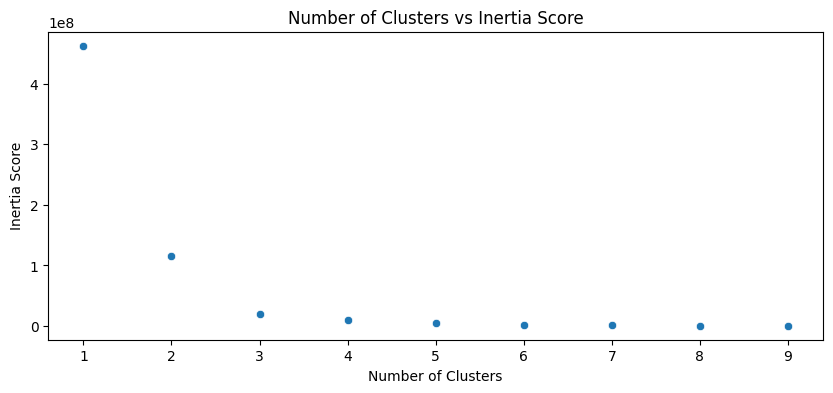

In [ ]:
plt.figure(figsize=(10,4))
sns.scatterplot(x=number_clusters, y= inertias)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia Score")
plt.title("Number of Clusters vs Inertia Score")
plt.show()

### KMeans

In [ ]:
from sklearn.cluster import KMeans
kmeans_model = KMeans(n_clusters=3, random_state = 42, n_init = 10)
clusters = kmeans_model.fit_predict(df_pca_fb)

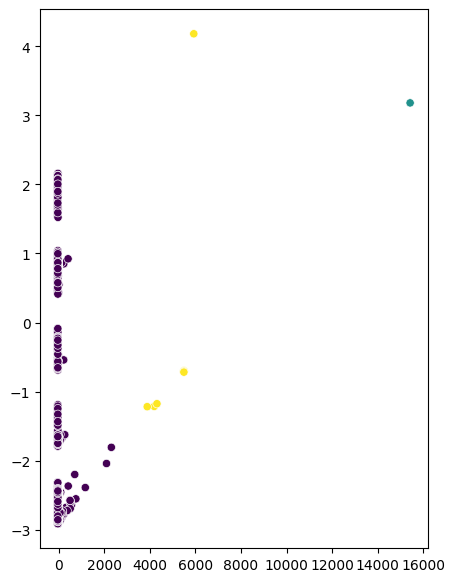

In [ ]:
plt.figure(figsize=(5,7))
sns.scatterplot(x=df_pca_fb[:,0], y=df_pca_fb[:,1], c=clusters)
plt.show()

### Topic Classification

In [ ]:
from transformers import pipeline
from tqdm.notebook import tqdm

In [ ]:
topic_classifier = pipeline("zero-shot-classification", model = 'facebook/bart-large-mnli')
df_fb_smaller = df_fb[:30] # Re-initialize df_fb_smaller to be a DataFrame
customer_reviews = df_fb_smaller["content"].tolist()
candidate_topics = [
    "sentiment_analysis",
    "spam_detection",
    "fake_review_detection",
    "rating_prediction",
    "topic_modeling",
    "emotion_detection",
    "bug_detection",
    "review_summarization",
    "keyword_extraction",
    "review_classification",
    "toxicity_detection",
    "review_clustering",
    "trend_analysis",
    "recommendation_system",
    "user_satisfaction_analysis",
    "app_feature_analysis",
    "complaint_detection",
    "intent_detection",
    "language_detection",
    "sarcasm_detection"
]
topics = []
for review in tqdm(customer_reviews, desc="Classifying topics"):
  result = topic_classifier(review, candidate_topics)
  topic = result["labels"][0]
  topics.append(topic)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Classifying topics:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
df_fb_smaller['topics'] = topics
df_fb_smaller[['content','topics']]


/tmp/ipykernel_16338/1402502343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fb_smaller['topics'] = topics


,content,topics
0,"I used Facebook for selling local products, and it used to be great. But recently, it’s become extremely frustrating. Accounts and Marketplace access are getting randomly restricted or banned with no clear reason or warning. There’s no transparency at all, and the support system is completely useless. It’s now very difficult to run a small business like this. Honestly, Facebook is no longer a reliable platform for selling..",complaint_detection
1,"I'm not receiving notifications on Facebook like I'm suppose to. I've reported this problem several times a day since April 27, 2026 and nothing has been done about it. I have my settings setup to receive notifications from groups I belong to and setup to receive notifications from a lot of the pages I follow and haven't been receiving any notifications from them.",complaint_detection
2,"I used Facebook mainly for selling local products, and it used to be a great platform for that. But over the past month or so, things have gotten really frustrating. AI systems seem to be randomly suspending Marketplace access or banning accounts without any clear reason.There’s little to no explanation provided, and the support system is not helpful at all. It’s become very difficult to run a small business this way. Because of this, Facebook is no longer useful for me as a selling platform,",user_satisfaction_analysis
3,"its all a pay to play now, robs you of views and traffic unless you pay them for verification badge and pay to promote. this business has just become so greedy that you cant have a presents unless you pay them or act as if its a job to post 3 4 times a day. and do reels. I dont want to live on your app. all they have done is make it harder to get the reach.",complaint_detection
4,"My admin account was wrongfully disabled after I reported it being hacked. My business pages had been hijacked and are under the hackers' control. I tried every avenue to re-enstate my account and reclaim my business pages, but I got nowhere. I have evidence to prove everything, but I can't get anyone from Meta to help me.",rating_prediction
5,"The audio in a lot of the reels is awful! Please fix the audio. It sounds like someone is purposely cutting the words. Every other word is heard, barely.",complaint_detection
6,absolutely hate that my shortcut bar was moved from the top of the app screen and is now stuck on the bottom with no way to move it back to the top... why change things that aren't broken...atleast give us a way to put it back how it was,review_clustering
7,Not working properly. I can't view or share videos that have been sent to me. Conversations won't load. This happens entirely too often.,review_classification
8,please put all the icons back at the top of the screen don't have them on the bottom the home screen the marketplace the messages all that you moved to the bottom and it's terrible,complaint_detection
9,I logged out of my account on my tablet and now can't log back in. I tried all the options and it doesn't work. However I can log in on my phone. What is the problem?,user_satisfaction_analysis


In [ ]:
df_fb_smaller['topics'].value_counts()

,count
topics,
user_satisfaction_analysis,6
review_classification,6
complaint_detection,5
recommendation_system,4
review_clustering,2
intent_detection,2
rating_prediction,1
app_feature_analysis,1
language_detection,1


### Exploratory Analysis

### Conclusion

### LLM Integration

- Sir said that we cannot be replaced by AI because there is no accountability in their findings.

- I'll use this to import an LLM to explain why they laid off a person or why they came to a conclusion

- The way I'd use an LLM for the project is to gain a reasoning model